# Toy Example

Esse notebook apresenta a implementação do Toy Example proposto.
Sua proposta segue os seguintes objetivos:
* Ele contém um modelo base, onde ocorrerá testes de justiça, implementação de algoritmos contra viés, e aplicação de metodologias de explicabilidade. 
* Seu papel é ser educativo, não apresentando um modelo para uso real, mas ilustrando o uso de IA em espaços de saúde, utilizando dados reais.

## Processamento dos dados

Os dados são de origem do Datasus, contendo informações das internações nos períodos de 2022 à novembro de 2025 (dados mais recentes quando feito esse Toy Example).

Devido ao tamanho dos dados brutos, não se encontram na página do Github. No entanto, a tabela final (após todo o pré processamento) se encontra em "Final_Table.zip". Apenas essa tabela é necessária para a execução do notebook. Para tal, descomprima o arquivo zip e coloque o arquivo "Final_Table.csv" (o único arquivo csv) dentro do diretório "SIH_Dados/".

O download dos dados foi feito por conexão ftp com o servidor disponibilizado pelo datasus: ftp.datasus.gov.br. Especificamente, os dados se encontram no diretório "/dissemin/publicos/SIHSUS/200801_/Dados/". Foram usados todos os arquivos que começam com "RD" e contém "22", "23", "24", "25", no quinto e sexto caractére (quando escrito esse notebook, exclui-se os dados de dezembro de 2025 e os dados de novembro de 2025 dos estados "AC" e "RR", pois não foram divulgados ainda).

A fim de evitar refazer grandes cálculos toda vez que esse notebook é executado, o processamento dos dados - filtragem de colunas de interesse e cálculo de novas colunas - foi feito previamente. No diretório SIH_Dados, encontram-se os scripts usados para cada etapa do processamento:
* dbc_dbf.py e dbf_csv.py: Transformam os arquivos de dados do formato dbc para dbf e dbf para csv, respectivamente.
* filtrar.py: Lê os arquivos csv, filtram as colunas (e o "target" de interesse, DIAG_PRIN = "J...") e salvam em novos csv.
* aggregate.py: Lê os novos arquivos csv, e calcula os valores agregados dos dados, agrupando-os por mes/ano e hospital. A tabela resultante é salva em "Aggregated_Table.csv".
* lag.py: Lê a tabelacao do passo anterior e calcula as variaveis "lag", usadas no modelo para predicao. A tabela, com todos os atributos que serão usados para o modelo final, é salva em um último csv: "Final_Table.csv".

O intuito de separar cada processo em seu próprio script é devido a robustez contra a possibilidade de erros ou mudanças, permitindo que alterações sejam feitas sem a necessidade de recomeçar o processo do zero. Além disso, cada script demora vários minutos, alguns até passando de uma hora, para terminar. Juntar todos os scripts em um resultaria em um programa que terminaria após várias horas.

## Documentação

Para essa versão, além do model card e do data card, será feito relatórios sobre a performance do modelo dentro das dimensões da IAR.

* model_card.pdf: Documentação que sumariza os detalhes, desempenho e observações sobre o modelo.
* data_card.md: Documentação completa sobre o dataset usado, com suas propriedades e processamento.
* metrics_report.md: Relatório das métricas usadas para análise do desempenho do modelo.
* fairness_report.md: Relatório dos passos tomados para verificar e amenizar viéses presentes no modelo.
* explainability_report.md: Relatório dos métodos de explicação usados para compreensão do comportamento do modelo, junto de explicações dos dados obtidos.

### Etapa 1: Criação do Modelo

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
import geopandas as gpd
import shap

df_read = pd.read_csv("./SIH_Data/Final_Table.csv")
df_read.dropna(inplace=True)

In [2]:
# Leakage features
leakage_columns = [
        "J00_06_share_lag0",
        "J09_18_share_lag0",
        "J20_22_share_lag0",
        "J40_47_share_lag0",
        "J_bucket_entropy_lag0",
        "J_death_share_lag0",
        "J_days_in_mean_lag0",
        "J_days_in_p90_lag0",
        "J_uti_share_lag0",
        "J_uti_days_mean_lag0",
        "J_val_tot_mean_lag0",
        "J_val_tot_p90_lag0",
        "J_val_uti_share_lag0",
        "J_sex_m_share_lag0",
        "J_sex_f_share_lag0",
        "J_age_60p_share_lag0",
        "J_age_15_59_share_lag0",
        "J_age_0_14_share_lag0",
        "J_race_white_share_lag0",
        "J_race_black_share_lag0",
        "J_race_others_share_lag0",
        "J_missing_race_share_lag0",
        "catchment_munic_unique_lag0",
        "catchment_top1_share_lag0",
        "catchment_entropy_lag0",
        "catchment_outside_local_share_lag0",
        "J_missing_diag_sec_share_lag0",
        "J_missing_proc_share_lag0",
]

df_leak = df_read
df_no_leak = df_read.drop(columns=leakage_columns)

In [3]:
def split (df):
    x_Train = df[(df.year >= 2022) & (df.year <= 2024)]
    x_Train = x_Train[(x_Train.year < 2024) | (x_Train.month <= 6)].reset_index(drop=True)
    y_Train = x_Train["J_count"]
    x_Train.drop(columns=["region", "CNES", "J_count"], inplace=True)

    x_Valid = df[(df.year == 2024) & (df.month >= 7)].reset_index(drop=True)
    y_Valid = x_Valid["J_count"]
    x_Valid.drop(columns=["region", "CNES", "J_count"], inplace=True)

    x_Test = df[df.year == 2025].reset_index(drop=True)
    y_Test = x_Test["J_count"]
    x_Test.drop(columns=["region", "CNES", "J_count"], inplace=True)

    return x_Train, y_Train, x_Valid, y_Valid, x_Test, y_Test

X_Train, Y_Train, X_Valid, Y_Valid, X_Test, Y_Test = split(df_no_leak)
X_Train_l, Y_Train_l, X_Valid_l, Y_Valid_l, X_Test_l, Y_Test_l = split(df_leak)


#### Baseline model

In [4]:
baseline = sk.linear_model.LinearRegression().fit(X_Train, Y_Train)

results_base = baseline.predict(X_Test)

#### LightGBM

In [5]:
lgb_train = lgb.Dataset(X_Train, Y_Train)
lgb_valid = lgb.Dataset(X_Valid, Y_Valid)

results_lgb = []

for i in range (5):
    seed = 778 - 10 * i
    lightgbm = lgb.train(params={"objective": "poisson", "seed": seed}, train_set=lgb_train, valid_sets=lgb_valid, callbacks=[lgb.early_stopping(stopping_rounds=5)])
    results_lgb.append(lightgbm.predict(X_Test, num_iteration=lightgbm.best_iteration))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011866 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24165
[LightGBM] [Info] Number of data points in the train set: 56250, number of used features: 104
[LightGBM] [Info] Start training from score 3.523175
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's poisson: -99.8808
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012468 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24165
[LightGBM] [Info] Number of data points in the train set: 56250, number of used features: 104
[LightGBM] [Info] Start training from score 3.523175
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's poisson: -99.8808
[LightGBM] [Info] Auto-choos

#### LightGBM, with leakage

In [6]:
lgb_train_l = lgb.Dataset(X_Train_l, Y_Train_l)
lgb_valid_l = lgb.Dataset(X_Valid_l, Y_Valid_l)

results_lgb_l = []

for i in range (5):
    seed = 778 - 10 * i
    lightgbm_l = lgb.train(params={"objective": "poisson", "seed": seed}, train_set=lgb_train_l, valid_sets=lgb_valid_l, callbacks=[lgb.early_stopping(stopping_rounds=5)])
    results_lgb_l.append(lightgbm_l.predict(X_Test_l, num_iteration=lightgbm_l.best_iteration))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023687 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30600
[LightGBM] [Info] Number of data points in the train set: 56250, number of used features: 130
[LightGBM] [Info] Start training from score 3.523175
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's poisson: -100.217
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023162 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30600
[LightGBM] [Info] Number of data points in the train set: 56250, number of used features: 130
[LightGBM] [Info] Start training from score 3.523175
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's poisson: -100.217
[LightGBM] [Info] Auto-choos

#### Métricas gerais para desempenho dos modelos:

In [7]:
df_results = df_no_leak[["year", "month", "CNES", "hospital_size", "region"]][df_no_leak.year == 2025].reset_index(drop=True)

df_results["Target"] = Y_Test
df_results["Base results"] = results_base
for i in range(5):
    df_results["LightGBM results " + str(i)] = results_lgb[i]
for i in range(5):
    df_results["Leaked LGB results " + str(i)] = results_lgb_l[i]

### Etapa 2: Avaliação de Justiça Inicial

Verifica-se se há disparidade de desempenho para diferentes grupos sociais. Como os valores são agregados, para fazer essa verificação, é necessário categorizar cada linha com qual grupo é mais representado. Por exemplo, se há mais mulheres que homens, então aquela linha será categorizada como "Fem" quanto a sexo.

Além disso, os valores estão em três "lags" diferentes. Assim, para determinar em quais casos o grupo é maioria, fazemos uma média dos três valores (exceto regiões, que apenas verifica a quantidade de amostras totais há com ela).

Quanto as métricas usadas, será usado o SMAPE (Symmetric mean absolute percentage error) para observar as diferenças. Não foi usado MAE e RMSE pois ambos trabalham com valores absolutos, assim dados com baixa amostra resultaram em valores menores, mesmo possuindo uma taxa de erro maior.

In [8]:
def categ_age(row):
    mean_60p = ((row["J_age_60p_share_lag1"] + row["J_age_60p_share_lag3"] + row["J_age_60p_share_lag12"]) / 3)
    mean_15_59 = ((row["J_age_15_59_share_lag1"] + row["J_age_15_59_share_lag3"] + row["J_age_15_59_share_lag12"]) / 3)
    mean_0_14 = ((row["J_age_0_14_share_lag1"] + row["J_age_0_14_share_lag3"] + row["J_age_0_14_share_lag12"]) / 3)
    if mean_60p > mean_0_14 and mean_60p > mean_15_59:
        return "60+"
    if mean_15_59 > mean_0_14:
        return "15-59"
    return "0-14"


def categ_sex(row):
    if (row["J_sex_m_share_lag1"] + row["J_sex_m_share_lag3"] + row["J_sex_m_share_lag12"]) / 3 > (row["J_sex_f_share_lag1"] + row["J_sex_f_share_lag3"] + row["J_sex_f_share_lag12"]) / 3:
        return "Male"
    return "Female"


def categ_race(row):
    mean_white = ((row["J_race_white_share_lag1"] + row["J_race_white_share_lag3"] + row["J_race_white_share_lag12"]) / 3)
    mean_black = ((row["J_race_black_share_lag1"] + row["J_race_black_share_lag3"] + row["J_race_black_share_lag12"]) / 3)
    mean_others = ((row["J_race_others_share_lag1"] + row["J_race_others_share_lag3"] + row["J_race_others_share_lag12"]) / 3)
    if mean_white > mean_black and mean_white > mean_others:
        return "White"
    if mean_black > mean_others:
        return "Black"
    return "Others"

In [9]:
df_results["category_age"] = X_Test.apply(categ_age, axis=1)
df_results["category_sex"] = X_Test.apply(categ_sex, axis=1)
df_results["category_race"] = X_Test.apply(categ_race, axis=1)

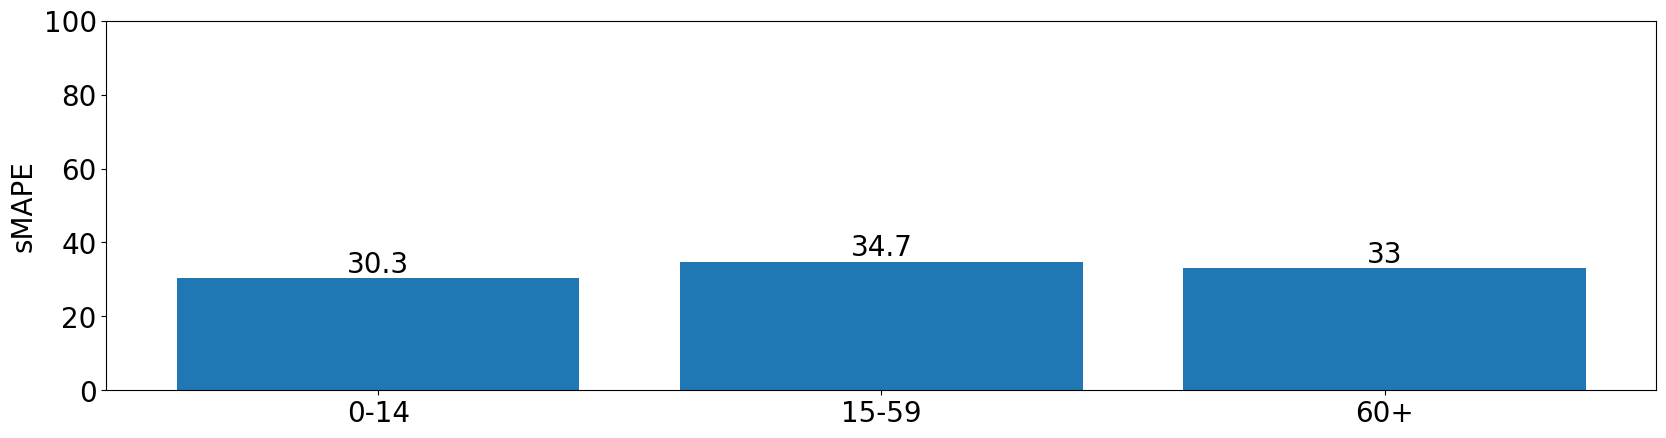

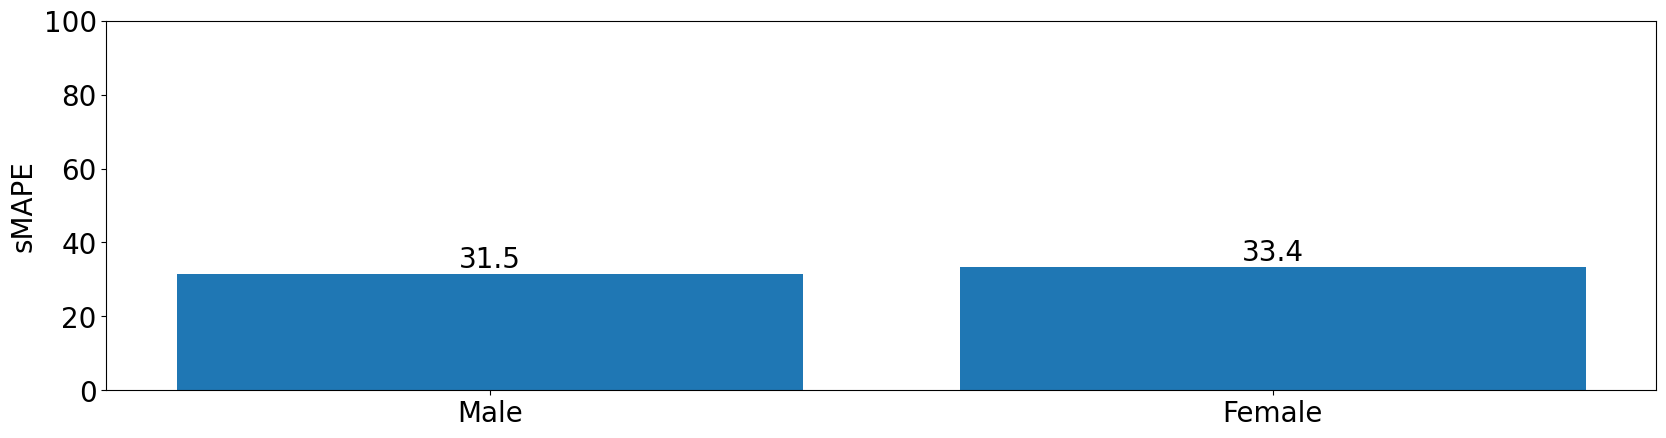

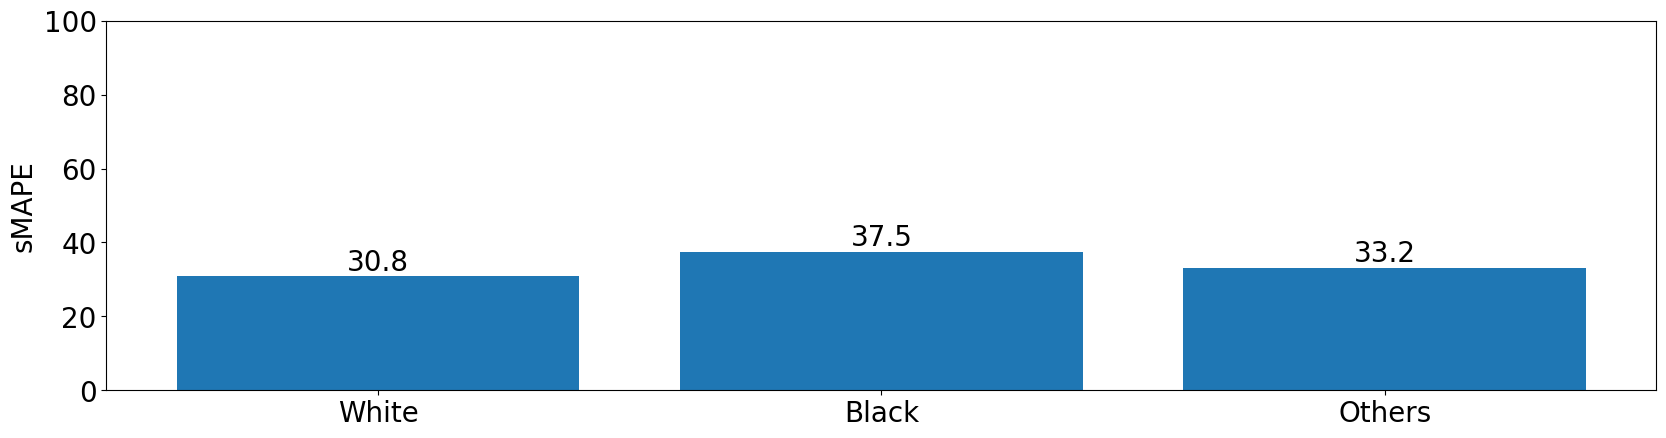

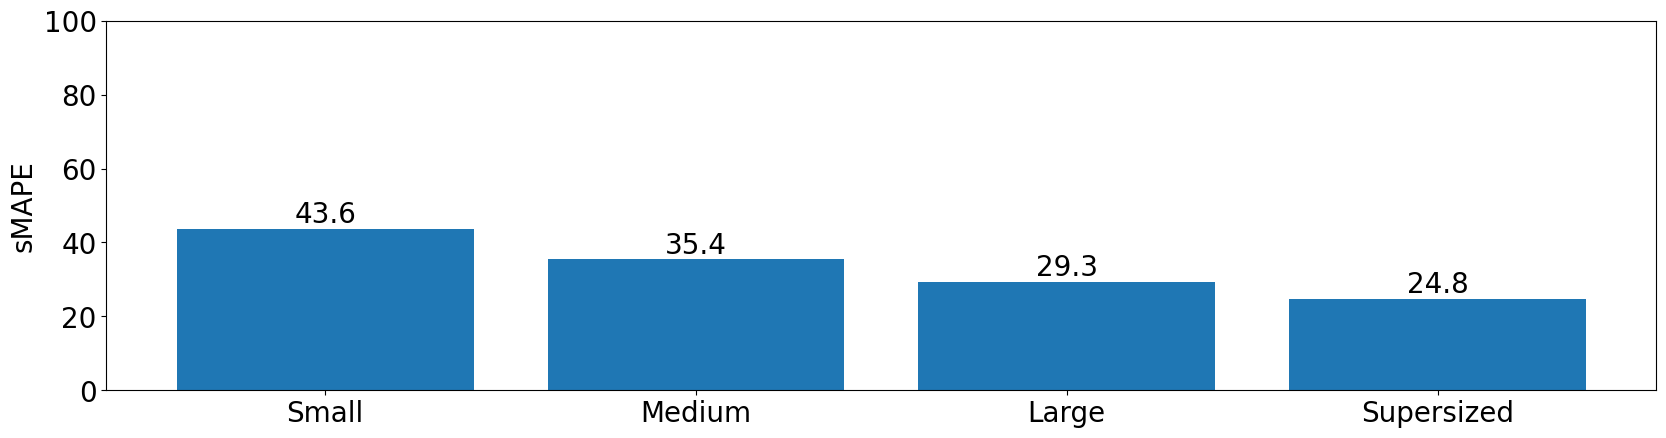

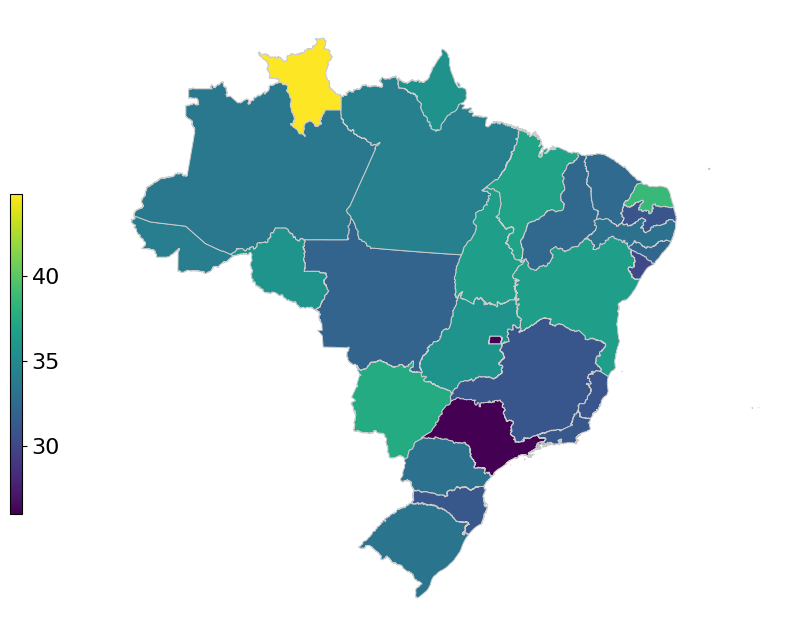

In [10]:
# SMAPE #
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def check_bias(df, title, category, lgb_model):
    keys = df[category].unique()
    if (category == "category_race"):
        keys = ["White", "Black", "Others"]
    elif (category == "hospital_size"):
        keys = sorted(keys)
    lgb_vals = []
    for key in keys:
        df_temp = df[df[category] == key]
        lgb_vals_ar = []
        for i in range (5):
            lgb_vals_ar.append(smape(df_temp["Target"], df_temp[lgb_model + str(i)]))
        lgb_vals.append(round(np.mean(lgb_vals_ar), 1))

    fig = plt.figure()
    fig.set_figwidth(20)
    plt.rc('font', size=20)
    plt.rc('xtick', labelsize=20)
    plt.rc('ytick', labelsize=20)
    plt.rc('figure', labelsize=20)
    
    bars = plt.bar(keys, lgb_vals)
    plt.bar_label(bars)
    if (category == "hospital_size"):
        plt.xticks(np.arange(4), ["Small", "Medium", "Large", "Supersized"])
    plt.ylabel("sMAPE")
    plt.ylim(0, 100)
    plt.show()

def check_region_bias(df, title, lgb_model):
    keys = sorted(df.region.unique())
    lgb_vals = []
    for key in keys:
        df_temp = df[df.region == key]
        lgb_vals_ar = []
        for i in range (5):
            lgb_vals_ar.append(smape(df_temp["Target"], df_temp[lgb_model + str(i)]))
        lgb_vals.append(round(np.mean(lgb_vals_ar), 1))

    df_map = gpd.read_file("./Map/BR_UF_2024.shp")[["SIGLA_UF", "geometry"]].sort_values("SIGLA_UF")
    df_map["smape"] = lgb_vals
    df_map.reset_index(inplace=True, drop=True)

    fig, ax = plt.subplots(1, figsize=(12, 8))
    plt.rc('ytick', labelsize=16)
    ax.axis("off")
    df_map.plot(column="smape", ax=ax, edgecolor="0.8", linewidth=0.7, cmap="viridis")
    colormap = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=min(df_map["smape"]), vmax=max(df_map["smape"])), cmap="viridis")
    colormap._A = []
    cbaxes = fig.add_axes([0.15, 0.25, 0.01, 0.4])
    cbar = fig.colorbar(colormap, cax=cbaxes)

check_bias(df_results, "AGE", "category_age", "LightGBM results ")
check_bias(df_results, "SEX", "category_sex", "LightGBM results ")
check_bias(df_results, "RACE", "category_race", "LightGBM results ")
check_bias(df_results, "SIZE", "hospital_size", "LightGBM results ")
check_region_bias(df_results, "REGION", "LightGBM results ")

A métrica SMAPE verifica em até quantos porcento o modelo erra (por exemplo, erramos em GO até 50% do valor correto, pelo modelo LightGBM). Isso significa que valores maiores representam performance pior do modelo, indicando uma taxa de erro maior.

Como houve um melhor desempenho pelo modelo LightGBM, todas as referências a resultados obtido de agora em diante sempre referenciarão valores obtidos por esse modelo.



#### Primeira análise

Observa-se que, quanto às categorias de idade, sexo e raça, os resultados não possuem disparidade excessivas, possuindo uma diferença de até 7% (a maior diferença está na comparação entre pessoas pretas e de outras raças, 7%).

No entanto, esse estudo revela uma grande diferença de performance entre os estados. A maioria permanece na casa dos 40% e 50%, porém o pior caso chega ao 70% (RR) e o melhor ao 31% (SE e TO).

### Etapa 3: Mitigação de viés
Para reduzir o viés apresentado, será implementado reamostragem, uma estratégia que visa igualar o número de amostras entre diferentes grupos. Essa estratégia é usada principalmente para modelos de classificação, porém pode ser útil para outros tipos de modelo também.

Para tal, primeiro verifica-se quantas amostras há para cada grupo.

Note que a reamostragem (criação de dados sintéticos) é feita apenas nos dados de treinamento.

In [11]:
X_Train = df_no_leak[(df_no_leak.year >= 2022) & (df_no_leak.year <= 2024)]
X_Train = X_Train[(X_Train.year < 2024) | (X_Train.month <= 6)].reset_index(drop=True)
Y_Train = X_Train["J_count"]

In [12]:
def check_header(group):
    print("\n\t", group.upper())
    print("--------+---------------------")
    print("group\t|\t Total")
    print("--------+---------------------")

def check_row(key, val):
    print(key, "\t|\t", val)


def check_age(df):
    df["category_age"] = df.apply(categ_age, axis=1)

    check_header("Age")
    check_row("60+", df[df.category_age == "60+"].shape[0])
    check_row("15-59", df[df.category_age == "15-59"].shape[0])
    check_row("0-14", df[df.category_age == "0-14"].shape[0])

    df.drop(columns="category_age", inplace=True)


def check_sex(df):
    df["category_sex"] = df.apply(categ_sex, axis=1)

    check_header("Sex")
    check_row("Male", df[df.category_sex == "Male"].shape[0])
    check_row("Female", df[df.category_sex == "Female"].shape[0])
    
    df.drop(columns="category_sex", inplace=True)

def check_race(df):
    df["category_race"] = df.apply(categ_race, axis=1)

    check_header("Race")
    check_row("White", df[df.category_race == "White"].shape[0])
    check_row("Black", df[df.category_race == "Black"].shape[0])
    check_row("Others", df[df.category_race == "Others"].shape[0])
    
    df.drop(columns="category_race", inplace=True)

def check_region(df):

    check_header("Region")

    regioes = df["region"].unique()
    for reg in regioes:
        reg_count = df["region"][df.region == reg].count()
        check_row(reg, reg_count)


def check_size(df):

    check_header("Size")
    check_row("0", df[df.hospital_size == 0].shape[0])
    check_row("1", df[df.hospital_size == 1].shape[0])
    check_row("2", df[df.hospital_size == 2].shape[0])
    check_row("3", df[df.hospital_size == 3].shape[0])
    
check_age(X_Train)
check_sex(X_Train)
check_race(X_Train)
check_region(X_Train)
check_size(X_Train)

/tmp/ipykernel_50198/2182808403.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["category_age"] = df.apply(categ_age, axis=1)



	 AGE
--------+---------------------
group	|	 Total
--------+---------------------
60+ 	|	 32461
15-59 	|	 4145
0-14 	|	 19644


/tmp/ipykernel_50198/2182808403.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["category_sex"] = df.apply(categ_sex, axis=1)



	 SEX
--------+---------------------
group	|	 Total
--------+---------------------
Male 	|	 34056
Female 	|	 22194

	 RACE
--------+---------------------
group	|	 Total
--------+---------------------
White 	|	 21003
Black 	|	 241
Others 	|	 35006

	 REGION
--------+---------------------
group	|	 Total
--------+---------------------
MA 	|	 3127
BA 	|	 4594
CE 	|	 2908
RN 	|	 979
PR 	|	 3705
MG 	|	 6904
AC 	|	 243
SP 	|	 8027
RR 	|	 147
PA 	|	 2678
PI 	|	 1238
SC 	|	 2393
AL 	|	 480
SE 	|	 360
AM 	|	 963
GO 	|	 2119
PE 	|	 2442
MS 	|	 1136
TO 	|	 467
RO 	|	 761
DF 	|	 331
MT 	|	 1365
ES 	|	 913
PB 	|	 1145
RS 	|	 4011
AP 	|	 170
RJ 	|	 2644

	 SIZE
--------+---------------------
group	|	 Total
--------+---------------------
0 	|	 10304
1 	|	 14517
2 	|	 15534
3 	|	 15895


/tmp/ipykernel_50198/2182808403.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["category_race"] = df.apply(categ_race, axis=1)


#### Análise:

Como se pode ver, alguns estados possui poucos dados sobre eles, com valores abaixo dos 1000 dados. Pelo outro lado, há estados que superam os 6000, como MG e SP. 

Vale notar também que há grandes diferenças em outros dados também, como pessoas com 15 a 59 anos e pessoas de raça preta, que contém uma quantidade menor de dados quanto aos outros grupos. No entanto, não é necessário fazer alterações nesses grupos, uma vez que não há disparidade de eficiência do modelo.

#### Correção:

A ferramenta usada para o trabalho de reamostragem é SMOTENC, uma versão de SMOTE capaz de lidar com valores categóricos. SMOTE é uma ferramenta de reamostragem geral, capaz de criar dados sintéticos para suprir o dataset com dados extras de grupos minoritários. Seu método é a criação de dados usando dados vizinhos (k-neighbors) para mesclar valores em um dado.

Para esse caso, a reamostragem busca igualar o número de amostras entre estados.

**Obs:**
* Essa célula pode demorar para finalizar (por volta de 5 minutos).
* Foi testado diversas combinações de aumento de amostras (over-sampling) e remoção de amostras (under-sampling) de vários grupos (inclusive de grupos com menor disparidade de desempenho). Notou-se que não houve melhora na disparidade, apenas piorando o desempenho geral do modelo.  

In [13]:
from imblearn.over_sampling import SMOTENC

# 18979 = 18.3
seed = 18979

smo = SMOTENC(random_state=seed, categorical_features=["CNES", "hospital_size"])

x_sample, y_sample = smo.fit_resample(X_Train.drop(columns="region"), X_Train["region"])
x_sample["region"] = y_sample

print(x_sample.shape)

(216729, 113)


/tmp/ipykernel_50198/4282779167.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x_sample["region"] = y_sample


Finalizado, refaz-se a verificação. Observa-se que os estados agora contém uma quantidade similar de dados.

In [14]:
x_sample.reset_index(inplace=True, drop=True)


check_age(x_sample)
check_sex(x_sample)
check_race(x_sample)
check_region(x_sample)
check_size(x_sample)

/tmp/ipykernel_50198/2182808403.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["category_age"] = df.apply(categ_age, axis=1)



	 AGE
--------+---------------------
group	|	 Total
--------+---------------------
60+ 	|	 109027
15-59 	|	 15918
0-14 	|	 91784


/tmp/ipykernel_50198/2182808403.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["category_sex"] = df.apply(categ_sex, axis=1)



	 SEX
--------+---------------------
group	|	 Total
--------+---------------------
Male 	|	 138578
Female 	|	 78151


/tmp/ipykernel_50198/2182808403.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["category_race"] = df.apply(categ_race, axis=1)



	 RACE
--------+---------------------
group	|	 Total
--------+---------------------
White 	|	 42615
Black 	|	 569
Others 	|	 173545

	 REGION
--------+---------------------
group	|	 Total
--------+---------------------
MA 	|	 8027
BA 	|	 8027
CE 	|	 8027
RN 	|	 8027
PR 	|	 8027
MG 	|	 8027
AC 	|	 8027
SP 	|	 8027
RR 	|	 8027
PA 	|	 8027
PI 	|	 8027
SC 	|	 8027
AL 	|	 8027
SE 	|	 8027
AM 	|	 8027
GO 	|	 8027
PE 	|	 8027
MS 	|	 8027
TO 	|	 8027
RO 	|	 8027
DF 	|	 8027
MT 	|	 8027
ES 	|	 8027
PB 	|	 8027
RS 	|	 8027
AP 	|	 8027
RJ 	|	 8027

	 SIZE
--------+---------------------
group	|	 Total
--------+---------------------
0 	|	 39647
1 	|	 56039
2 	|	 54346
3 	|	 66697


### Etapa 4: Reimplementação do modelo e Reavaliação

Com os novos dados, o modelo é treinado novamente para verificação do novo desempenho.

In [15]:
X_Train = x_sample
Y_Train = X_Train["J_count"]
X_Train.drop(columns=["region", "CNES", "J_count"], inplace=True)

In [16]:
# LightGBM Fairness #

lgb_train_f = lgb.Dataset(X_Train, Y_Train)
lgb_valid_f = lgb.Dataset(X_Valid, Y_Valid)

# Saving for explicability section
lgb_for_explanation = []

results_lgb_f = []

for i in range (5):
    seed = 778 - 10 * i
    lgb_fair = lgb.train(params={"objective": "poisson", "seed": seed}, train_set=lgb_train_f, valid_sets=lgb_valid_f, callbacks=[lgb.early_stopping(stopping_rounds=5)])
    results_lgb_f.append(lgb_fair.predict(X_Test, num_iteration=lgb_fair.best_iteration))
    if i == 4:
        lgb_for_explanation = lgb_fair

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054753 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25289
[LightGBM] [Info] Number of data points in the train set: 216729, number of used features: 104
[LightGBM] [Info] Start training from score 3.576710
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[96]	valid_0's poisson: -99.8551
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.068292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25289
[LightGBM] [Info] Number of data points in the train set: 216729, number of used features: 104
[LightGBM] [Info] Start training from score 3.576710
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[96]	valid_0's poisson: -99.8551
[LightGBM] [Info] Auto-choos

In [77]:
def compare_region_bias(df, title):
    keys = sorted(df.region.unique())
    lgb_vals = []
    lgb_f_vals = []
    for key in keys:
        df_temp = df[df.region == key]
        lgb_vals_ar = []
        lgb_f_vals_ar = []
        for i in range (5):
            lgb_vals_ar.append(smape(df_temp["Target"], df_temp["LightGBM results " + str(i)]))
            lgb_f_vals_ar.append(smape(df_temp["Target"], df_temp["LightGBM Fair results " + str(i)]))
        lgb_vals.append(round(np.mean(lgb_vals_ar), 1))
        lgb_f_vals.append(round(np.mean(lgb_f_vals_ar), 1))

    df_map = gpd.read_file("./Map/BR_UF_2024.shp")[["SIGLA_UF", "geometry"]].sort_values("SIGLA_UF")
    df_map["smape"] = lgb_vals
    df_map["smape_f"] = lgb_f_vals
    df_map.reset_index(inplace=True, drop=True)

    for i in range (len(df_map["smape"])):
        print(df_map["smape"][i], df_map["smape_f"][i])
    
    fig, ax = plt.subplots(1, 2, figsize=(20, 8))
    ax[0].axis("off")
    ax[0].set_position([0.2, 0, 0.5, 1])
    ax[0].set_title("LightGBM", y=0)
    ax[1].axis("off")
    ax[1].set_position([0.6, 0, 0.5, 1])
    ax[1].set_title("Fairness LightGBM", y=0)
    plt.rc('ytick', labelsize=20)
    df_map.plot(column="smape", ax=ax[0], edgecolor="0.8", linewidth=0.5, cmap="viridis")
    df_map.plot(column="smape_f", ax=ax[1], edgecolor="0.8", linewidth=0.5, cmap="viridis")
    
    colormap = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=min(df_map["smape"]), vmax=max(df_map["smape"])), cmap="viridis")
    colormap._A = []
    cbaxes = fig.add_axes([0.125, 0.2, 0.015, 0.6])
    cbar = fig.colorbar(colormap, cax=cbaxes)

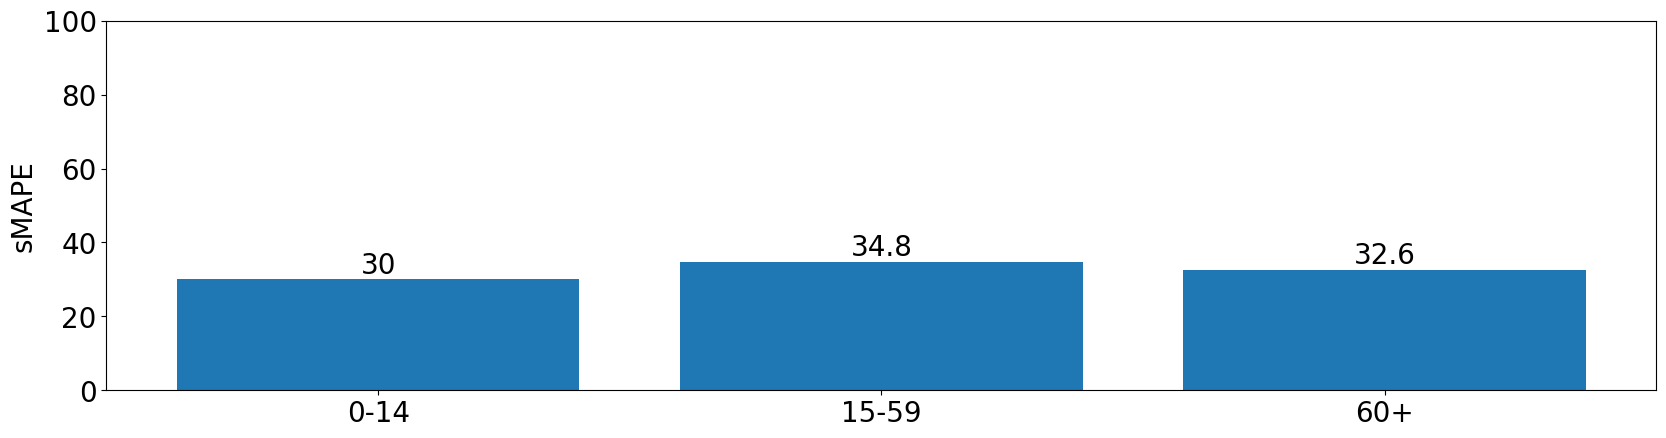

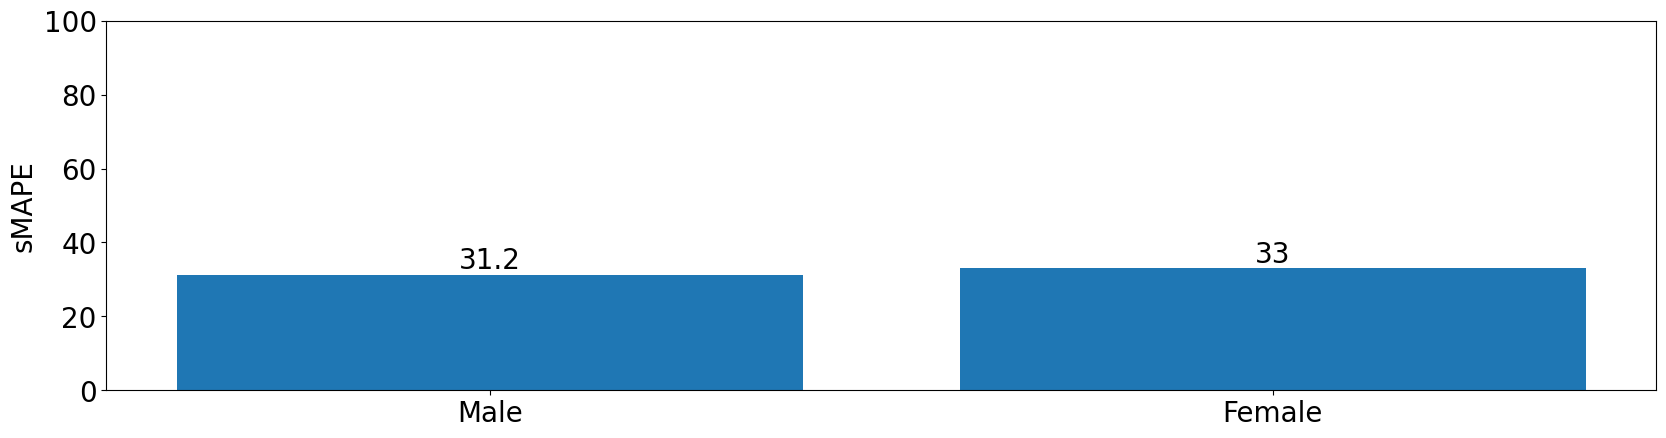

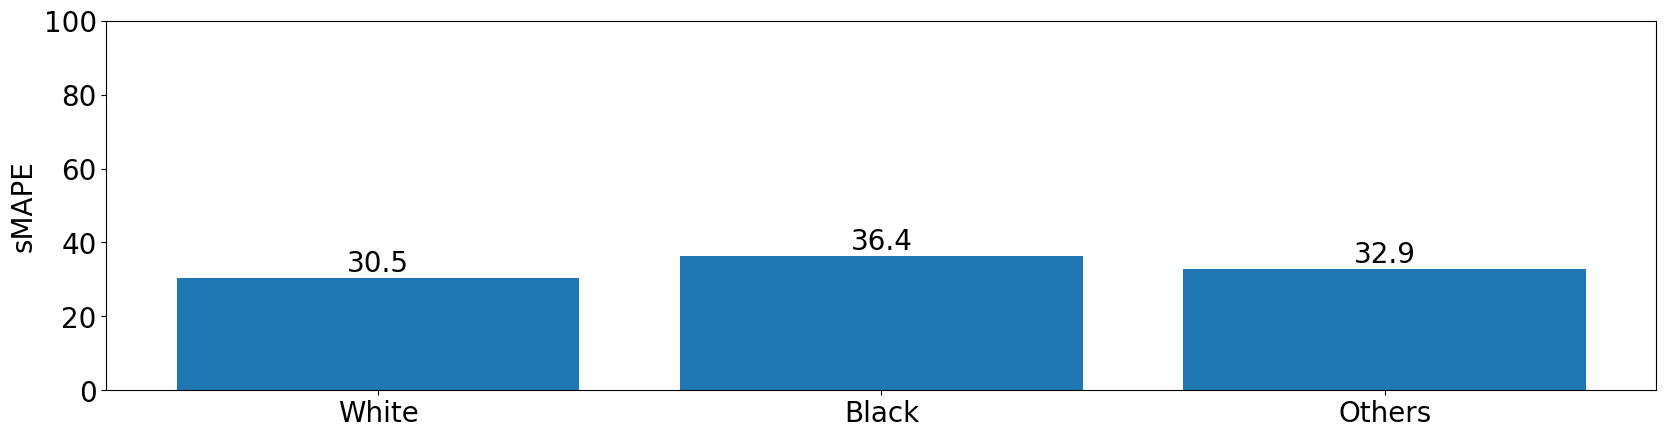

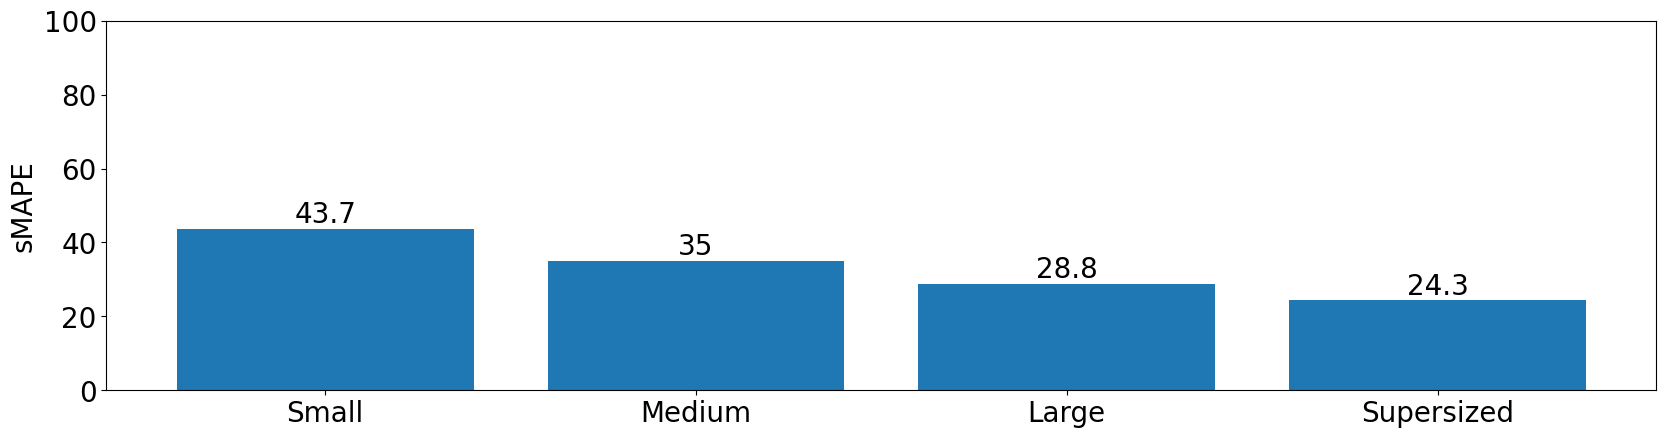

33.9 33.7
32.1 31.7
33.5 33.1
35.6 36.7
36.5 36.0
32.4 32.4
26.0 26.7
30.9 30.6
35.7 35.2
36.9 37.0
31.0 30.5
37.5 36.8
32.0 31.5
34.1 33.7
30.9 30.2
33.1 33.0
32.3 32.3
33.0 32.7
31.1 30.5
38.7 38.8
35.7 35.4
44.8 43.9
33.2 32.7
31.1 31.0
30.1 31.0
26.0 25.6
36.5 36.7


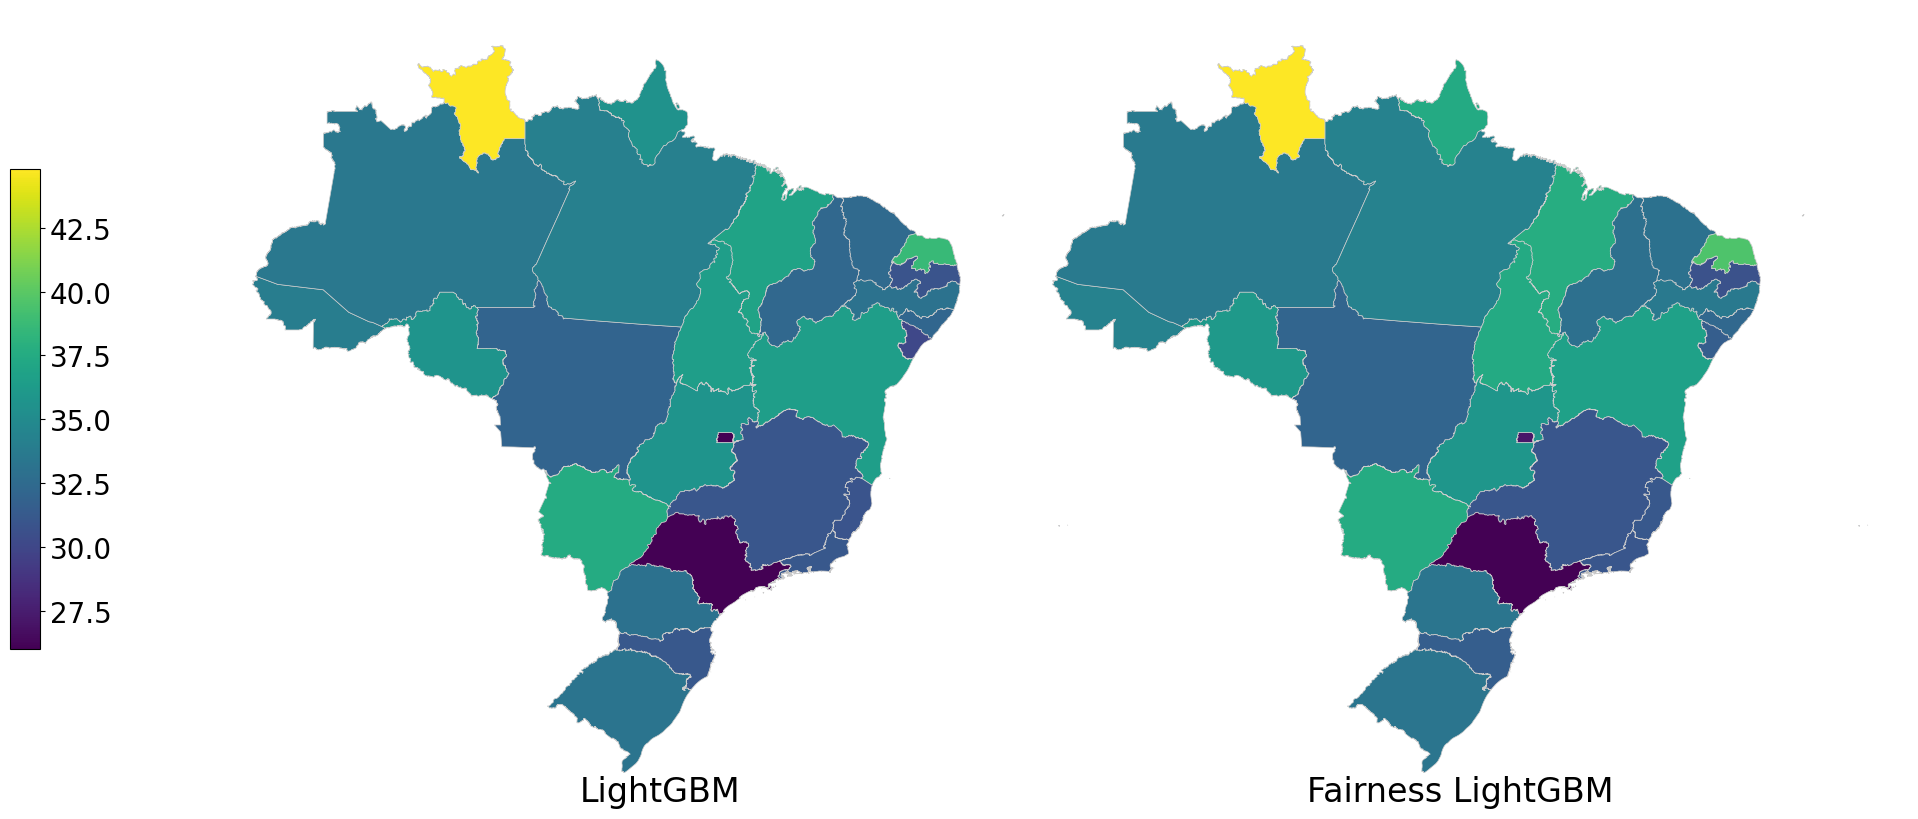

In [78]:
for i in range(5):
    df_results["LightGBM Fair results " + str(i)] = results_lgb_f[i]


check_bias(df_results, "AGE", "category_age", "LightGBM Fair results ")
check_bias(df_results, "SEX", "category_sex", "LightGBM Fair results ")
check_bias(df_results, "RACE", "category_race", "LightGBM Fair results ")
check_bias(df_results, "SIZE", "hospital_size", "LightGBM Fair results ")
compare_region_bias(df_results, "REGION")

#### Segunda Análise 

Observa-se que o resultado da amostragem foi reduzir levemente os valores estaduais em geral. O pior caso desceu para 62% (PB) e o melhor desceu para 28% (SE). A diferença ainda é grande, mas a disparidade desceu de 39% para 34%, além de melhorar um pouco a performance do modelo.

O objetivo de algoritmos e metodologias para mitigação de viés é apenas esse, reduzir a diferença de performance entre diferentes grupos. Comumente, esses métodos levaram a uma pior performance geral do modelo, em troca de um modelo mais justo.

A reamostragem teve mínimo impacto no desempenho nas outras categorias. É possível que, em casos onde o impacto é perceptível, seja útil implementar reamostragem nos outros dados, ou experimentar outros métodos de mitigação de viés.

#### Métricas gerais pós justiça 

In [19]:
jdaskjdajkadjk
def plot_results(title, metric, base_res, lgb_res, lgb_l_res, lgb_f_res):
    fig = plt.figure()
    fig.set_figwidth(10)
    
    bars = plt.bar(["Baseline", "LightGBM", "Leaked LGB", "Fairness LGB"], [base_res, lgb_res, lgb_l_res, lgb_f_res], color=["darkorchid", "crimson", "teal", "darkorange"])
    plt.bar_label(bars)
    plt.ylabel(metric)
    plt.ylim(0, max([base_res, lgb_res, lgb_l_res, lgb_f_res]) * 1.4)
#    plt.title(title)
    plt.show()

# ==== MAE ==== #

# Baseline:
base_mae = mean_absolute_error(y_true=Y_Test, y_pred=results_base)

# LightGBM:
lgb_mae_ar = []
for i in range(5):
    lgb_mae_ar.append(mean_absolute_error(y_true=Y_Test, y_pred=results_lgb[i]))
lgb_mae = np.mean(lgb_mae_ar)

# LightGBM, with leakage:
lgb_l_mae_ar = []
for i in range(5):
    lgb_l_mae_ar.append(mean_absolute_error(y_true=Y_Test, y_pred=results_lgb_l[i]))
lgb_l_mae = np.mean(lgb_l_mae_ar)

# LightGBM, post Fairness:
lgb_f_mae_ar = []
for i in range(5):
    lgb_f_mae_ar.append(mean_absolute_error(y_true=Y_Test, y_pred=results_lgb_f[i]))
lgb_f_mae = np.mean(lgb_f_mae_ar)

# ==== RMSE ==== #

# Baseline:
base_rmse = sqrt(mean_squared_error(y_true=Y_Test, y_pred=results_base))

# LightGBM:
lgb_rmse_ar = []
for i in range(5):
    lgb_rmse_ar.append(sqrt(mean_squared_error(y_true=Y_Test, y_pred=results_lgb[i])))
lgb_rmse = np.mean(lgb_rmse_ar)

# LightGBM, with leakage:
lgb_l_rmse_ar = []
for i in range(5):
    lgb_l_rmse_ar.append(sqrt(mean_squared_error(y_true=Y_Test, y_pred=results_lgb_l[i])))
lgb_l_rmse = np.mean(lgb_l_rmse_ar)

# LightGBM, post Fairness:
lgb_f_rmse_ar = []
for i in range(5):
    lgb_f_rmse_ar.append(sqrt(mean_squared_error(y_true=Y_Test, y_pred=results_lgb_f[i])))
lgb_f_rmse = np.mean(lgb_f_rmse_ar)

# ==== SMAPE ==== #

# Baseline:
base_smape = smape(y_true=Y_Test, y_pred=results_base)

# LightGBM:
lgb_smape_ar = []
for i in range (5):
    lgb_smape_ar.append(smape(y_true=Y_Test, y_pred=results_lgb[i]))
lgb_smape = np.mean(lgb_smape_ar)

# LightGBM, with leakage:
lgb_l_smape_ar = []
for i in range (5):
    lgb_l_smape_ar.append(smape(y_true=Y_Test, y_pred=results_lgb_l[i]))
lgb_l_smape = np.mean(lgb_l_smape_ar)

# LightGBM, post Fairness:
lgb_f_smape_ar = []
for i in range (5):
    lgb_f_smape_ar.append(smape(y_true=Y_Test, y_pred=results_lgb_f[i]))
lgb_f_smape = np.mean(lgb_f_smape_ar)

plot_results("MAE per Model", "MAE", base_mae, lgb_mae, lgb_l_mae, lgb_f_mae)
plot_results("RMSE per Model", "RMSE", base_rmse, lgb_rmse, lgb_l_rmse, lgb_f_rmse)
plot_results("sMAPE per Model", "sMAPE", base_smape, lgb_smape, lgb_l_smape, lgb_f_smape)

NameError: name 'jdaskjdajkadjk' is not defined

### Etapa 5: Explicação do modelo

Essa seção oferece explicações sobre o funcionamento do modelo.

Para tal usaremos a ferramenta SHAP. Ela é capaz de interpretar modelos e apresentar, por meio de gráficos, explicações sobre como cada atributo influencia o resultado obtido. Ele apresenta explicações gerais (como os atributos afetam os valores obtidos) e explicações locais (como, dado um dado, o ele chega ao resultado respectivo).

In [ ]:
explanation = shap.TreeExplainer(lgb_for_explanation)


# Calculate SHAP values for the test set
shap_values = explanation.shap_values(X_Test)



shap.initjs()

#### Waterfall (Explicação local)

Esse gráfico apresenta por quanto cada atributo (junto de seu valor) alterou a predição para um dado.

Por exemplo, para o primeiro dado do dataset, os mais impactantes foram "J_age_0_14_share_lag12", "hospital_porte", "J_count_ma12_lag1" e "J_age_0_14_share_lag1".

In [ ]:
shap.plots.waterfall(explanation(X_Test)[0])

Para o sexto dado (índice 5), no entanto, "J_age_0_14_share_lag12" não alterou o resultado substancialmente (apenas por 0.01, na verdade). Pelo outro lado, "J_count_ma12_lag1" foi o atributo que mais impactou. 

In [ ]:
shap.plots.waterfall(explanation(X_Test)[5])

##### Outros Exemplos:

In [ ]:
shap.plots.waterfall(explanation(X_Test)[100])

In [ ]:
shap.plots.waterfall(explanation(X_Test)[9038])

#### Sumário (Explicação global)

Esse gráfico apresenta quais atributos mais alteram o resultado, e quais valores tem impacto maior. Valores vermelhos indicam altos valores para o atributo e pontos distantes do centro vertical indicam alta influência, seja negativo ou positivo.  

Nesse caso, "J_count_ma12_lag1" possui um dos maiores impactos no modelo, especificamente quandos os valores são altos (afeta aumentando o valor).  

In [ ]:
shap.summary_plot(shap_values, X_Test, plot_type="dot", max_display=10)

\\ Pode calcular o Mean Absolute SHAP. Pegue a matriz de valores SHAP do conjunto de teste e, para cada feature, calcule o valor absoluto dos SHAPs e, em seguida, tire a média considerando todas as instâncias. Esse valor representa a importância média real da variável no comportamento global do modelo. Depois disso, some os valores médios de todas as features e calcule a porcentagem que cada variável representa em relação ao total. Isso ajuda reportar a contribuição percentual das principais variáveis no texto do artigo.

In [ ]:
mae_by_feature = sum(abs(shap_values)) / len(X_Test.columns)
feat_importance_percentage = 100 * mae_by_feature / sum(mae_by_feature)

for i in range (0, len(X_Test.columns)):
    print(f"{X_Test.columns[i]}: {round(mae_by_feature[i], 2)}, {round(feat_importance_percentage[i], 2)}%")

print(len(mae_by_feature))

#### Explicação por grupo:

Acompanhando a análise de justiça, verifica-se como os tributos afetam os resultados dependendo da região. Como o objetivo é olhar a região como um todo, será feito uma análise global, uma vez que uma anállise local dos dados não resultaria em uma observação do comportamento regional.

In [ ]:
fsedjh


X_Test["region"] = df_results["region"]

# Calculate SHAP values for the test set
for reg in X_Test['region'].unique():
    shap_values = explanation.shap_values(X_Test[X_Test.region == reg].drop(columns="region"))
    print("")
    print("=====================================")
    print(reg)
    shap.summary_plot(shap_values, X_Test[X_Test.region == reg].drop(columns="region"), plot_type="dot", max_display=10)